# Interpretabilidade e perguntas de negócio

Com a Árvore de Decisão fechada como modelo final (Achado 43 em `reports/decisoes.md`), este notebook cobre a última etapa técnica do projeto: entender de fato o que o modelo aprendeu, e usar isso pra responder as 5 perguntas de negócio do enunciado. Uso três técnicas de interpretabilidade que se complementam - importância nativa (rápida, mas com viés conhecido), Permutation Importance (mais robusta) e SHAP (explica tanto o modelo como um todo quanto uma escola específica) - e só depois de comparar as três é que confio no que sobrar de mais consistente entre elas pra responder as perguntas.

## 1. Dataset, split e metadado de agregação

Mesmo dataset e split dos notebooks anteriores, sem nenhuma mudança (`random_state=42`). A diferença aqui é que também guardo `id_escola`, `id_municipio` e `sigla_uf` à parte, alinhados pelo mesmo índice de X/y - essas colunas não entram no modelo (já são feature só no caso de `sigla_uf`, que continua no X normalmente), mas preciso delas soltas pra conseguir agregar risco previsto por município/estado na Seção 7, sem misturar isso com o que o modelo usa pra prever.

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

from src.preprocessing.pipeline import (
    carregar_dataset_modelagem, construir_preprocessador,
    FEATURES_NUMERICAS, FEATURES_CATEGORICAS,
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from src.preprocessing.build_base_escola import ler_base_escola_modelo
from src.visualization.graficos import plot_importancia_features, plot_arvore

pd.set_option("display.max_columns", 100)
# ============================================================
# PARAMETRO EXPERIMENTAL (Secao 2): incluir sigla_uf como feature?
# ============================================================
# Reparei que a importancia nativa e o SHAP ficaram dominados pelas
# categorias de sigla_uf (a maioria dos itens do topo do ranking e
# alguma variante de sigla_uf_xx), meio que ofuscando o peso das
# outras features (infraestrutura, corpo docente etc). Antes de decidir
# se isso e so um reflexo real de padrao regional forte ou se sigla_uf
# esta "engolindo" sinal de outras colunas correlacionadas, coloquei
# esse parametro pra treinar o mesmo modelo com e sem sigla_uf no
# conjunto de features e comparar as duas versoes de importancia/SHAP
# lado a lado. Isso NAO muda `src/preprocessing/pipeline.py` (a lista
# oficial de 47 features continua igual) - e so um experimento dentro
# deste notebook. O resultado (Secao 2.1) confirmou que sigla_uf deve
# ficar, e a lista final de features nao mudou.
INCLUIR_SIGLA_UF = True  # troque pra False pra rodar sem sigla_uf


In [2]:
X, y = carregar_dataset_modelagem()

# Metadado (id_escola, id_municipio, sigla_uf) alinhado pelo mesmo indice de X/y -
# nao entra no modelo, so serve pra agregar previsao por municipio/estado na Secao 7.
# `ler_base_escola_modelo()` ja tinha sido chamada dentro de `carregar_dataset_modelagem()`,
# entao essa segunda chamada usa o cache local, sem custo real de reprocessamento.
base_completa = ler_base_escola_modelo()
metadado = base_completa.loc[X.index, ["id_escola", "id_municipio", "sigla_uf"]]

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
metadado_validacao = metadado.loc[X_validacao.index]

print(f"Treino: {X_treino.shape}")
print(f"Validação: {X_validacao.shape}")

Lendo base_escola_modelo do cache local: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\data\processed\base_escola_modelo.parquet
Escolas com ideb preenchido: 42273 de 63537 (66.5%) - só essas entram no dataset de modelagem.
acesso_internet_computador: 1009 escolas com código 9 (não informado) -> viraram nulo.
tratamento_lixo_inexistente: 57 escolas com código 9 (não informado) -> viraram nulo.
tratamento_lixo_reciclagem: 57 escolas com código 9 (não informado) -> viraram nulo.
redes_sociais: 546 escolas com código 9 (não informado) -> viraram nulo.
Lendo base_escola_modelo do cache local: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\data\processed\base_escola_modelo.parquet
Treino: (33818, 47)
Validação: (8455, 47)


### 1.1 Curiosidade: distribuicao de `etapa_ensino_fundamental_anos_finais`

Toda escola desta base ja garante ter os anos iniciais - e o proprio recorte do alvo (`anos_escolares == "iniciais (1-5)"` dentro do `br_inep_ideb`, ver `src/preprocessing/build_base_escola.py`). A flag `etapa_ensino_fundamental_anos_finais` marca se a MESMA escola tambem oferece o ciclo seguinte (6o ao 9o ano). Antes de interpretar o efeito que essa feature mostrou no SHAP, quero ver como ela se distribui de verdade e se a proporcao que bate a meta muda entre quem oferece so os anos iniciais e quem oferece os dois ciclos.

In [3]:
base_modelagem_completa = base_completa.loc[X.index]

print("Distribuicao de etapa_ensino_fundamental_anos_finais (escolas usadas no modelo):")
print(base_modelagem_completa["etapa_ensino_fundamental_anos_finais"].value_counts(dropna=False))
print()
print(base_modelagem_completa["etapa_ensino_fundamental_anos_finais"].value_counts(normalize=True, dropna=False).round(3))
print()
print("Proporcao que bate a meta (alvo_ideb=1), por essa flag:")
print(base_modelagem_completa.groupby("etapa_ensino_fundamental_anos_finais")["alvo_ideb"].mean().round(3))


Distribuicao de etapa_ensino_fundamental_anos_finais (escolas usadas no modelo):
etapa_ensino_fundamental_anos_finais
0       23247
1       19002
<NA>       24
Name: count, dtype: Int64

etapa_ensino_fundamental_anos_finais
0        0.55
1        0.45
<NA>    0.001
Name: proportion, dtype: Float64

Proporcao que bate a meta (alvo_ideb=1), por essa flag:
etapa_ensino_fundamental_anos_finais
0    0.605
1    0.478
Name: alvo_ideb, dtype: Float64


## 2. Retreinar o modelo final (Árvore de Decisão, Achado 43)

Mesma configuração fechada no Achado 43: `criterion="gini"`, sem limitar `max_depth`, `min_samples_leaf=50`. Não salvei o modelo treinado em disco na etapa anterior, então retreino aqui do zero, no treino inteiro, e salvo o resultado na Seção 2.3 - é rápido, a Árvore é o candidato mais barato dos quatro (Achado 39).

### 2.1 Nota sobre o parametro `INCLUIR_SIGLA_UF`

Deixei um parametro logo na celula de imports (Secao 1) pra ligar/desligar `sigla_uf` do conjunto de features so nesta rodada exploratoria do notebook 12. A motivacao: nas primeiras rodadas, tanto a importancia nativa quanto o SHAP vieram dominados por categorias de `sigla_uf` (a maior parte do topo do ranking era alguma variante `sigla_uf_xx`), o que deixava dificil enxergar o peso relativo das outras 46 features (infraestrutura, corpo docente, orgaos colegiados etc). Quero comparar as duas versoes (com e sem `sigla_uf`) antes de tirar qualquer conclusao sobre quais fatores realmente mais pesam.

Com `INCLUIR_SIGLA_UF = False`, a celula abaixo monta um `ColumnTransformer` igual ao de `construir_preprocessador()` (mesma estrategia de imputacao/encoding), so que sem `sigla_uf` na lista de categoricas - as outras 46 features finais continuam todas presentes, nada mais muda.

**Resultado real:** com `sigla_uf`, acuracia de validacao 0,7315; sem `sigla_uf`, caiu pra 0,66 - uma queda de mais de 7 pontos percentuais, bem maior do que eu esperava antes de testar. Isso confirma que nao e um artefato do one-hot "inflando" a importancia de `sigla_uf` artificialmente: e sinal real, que as outras 46 features nao conseguem substituir. Decisao fechada: mantenho `INCLUIR_SIGLA_UF = True` como configuracao oficial (bate com o Achado 43), sem mudar `src/preprocessing/pipeline.py`.

In [4]:
FEATURES_CATEGORICAS_EXPERIMENTO = (
    FEATURES_CATEGORICAS if INCLUIR_SIGLA_UF
    else [f for f in FEATURES_CATEGORICAS if f != "sigla_uf"]
)
print(f"sigla_uf incluida como feature nesta rodada? {INCLUIR_SIGLA_UF}")
print(f"Categoricas usadas: {FEATURES_CATEGORICAS_EXPERIMENTO}")

# Mesma estrategia de imputacao/encoding de `construir_preprocessador()` (mediana pras numericas, categoria "desconhecido" + One-Hot pras categoricas) - monto na mao aqui so pra poder variar a lista de categoricas via `INCLUIR_SIGLA_UF`, sem mexer no `pipeline.py` oficial.
preprocessador_experimento = ColumnTransformer(transformers=[
    ("numericas", Pipeline([("imputador", SimpleImputer(strategy="median"))]), FEATURES_NUMERICAS),
    ("categoricas", Pipeline([
        ("imputador", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), FEATURES_CATEGORICAS_EXPERIMENTO),
])

pipe_final = Pipeline([
    ("prep", preprocessador_experimento),
    ("clf", DecisionTreeClassifier(
        criterion="gini", max_depth=None, min_samples_leaf=50, random_state=42,
    )),
])
pipe_final.fit(X_treino, y_treino)

acuracia_validacao = accuracy_score(y_validacao, pipe_final.predict(X_validacao))
print(f"Acuracia na validacao: {acuracia_validacao:.4f} (deve bater com o Achado 43: 0,7315, so quando INCLUIR_SIGLA_UF=True)")


sigla_uf incluida como feature nesta rodada? True
Categoricas usadas: ['tipo_regulamentacao', 'tipo_responsavel_regulamentacao', 'tipo_local_funcionamento_predio_escolar', 'tipo_rede_local', 'sigla_uf', 'tipo_localizacao', 'tipo_aee', 'tipo_atividade_complementar', 'rede']
Acuracia na validacao: 0.7315 (deve bater com o Achado 43: 0,7315, so quando INCLUIR_SIGLA_UF=True)


### 2.2 Experimento: `sigla_uf` como coluna unica (Ordinal, sem one-hot)

No item 2.1, `sigla_uf` ou entra completo (one-hot, uma coluna por UF) ou sai totalmente. Aqui testo uma terceira opcao: manter `sigla_uf` no modelo, mas codificada como uma unica coluna numerica (`OrdinalEncoder`, um codigo inteiro por UF) em vez de expandir em dummies - assim a importancia nativa da arvore aparece como UMA linha so pra `sigla_uf`, do mesmo jeito que a Permutation Importance ja mostra hoje (Secao 4).

**Ressalva importante:** o `OrdinalEncoder` atribui um numero inteiro arbitrario a cada UF - a ordem nao tem significado real (nao e como uma variavel realmente ordinal, tipo nivel de escolaridade). A Arvore de Decisao ainda consegue formar grupos arbitrarios de UFs atraves de varios splits sucessivos (ex.: `sigla_uf <= 14` e depois `sigla_uf <= 8`), mas fica mais dificil pra arvore isolar um estado especifico com um unico corte, como o one-hot permite. Ou seja: essa comparacao serve pra enxergar o tamanho agregado do sinal de `sigla_uf` de um jeito mais direto de ler - nao e uma codificacao 'melhor' que a oficial do `pipeline.py`, so mais facil de comparar lado a lado com as outras 46 features.

Acuracia na validacao (sigla_uf como coluna unica/ordinal): 0.7151


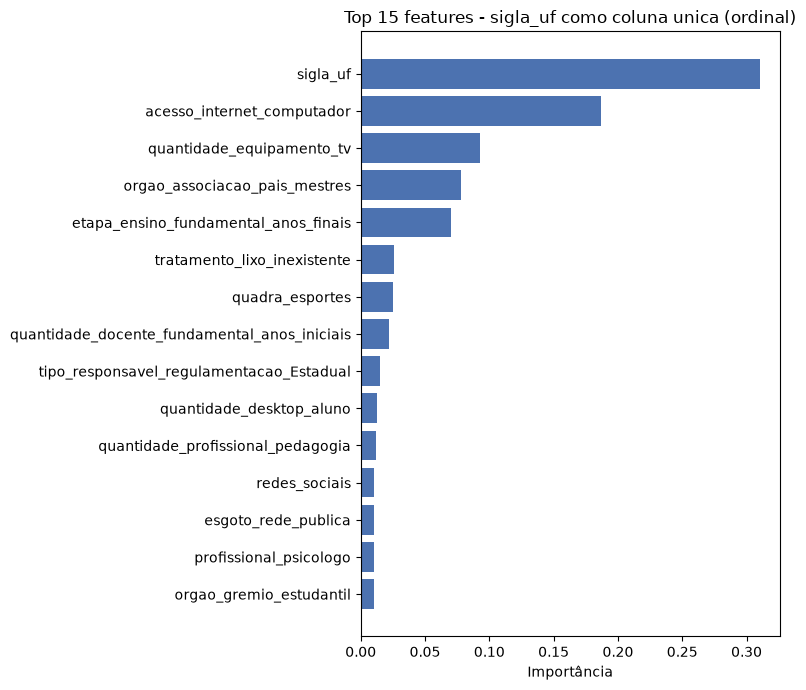

sigla_uf                                        0.310470
acesso_internet_computador                      0.186867
quantidade_equipamento_tv                       0.093060
orgao_associacao_pais_mestres                   0.077984
etapa_ensino_fundamental_anos_finais            0.070366
tratamento_lixo_inexistente                     0.025681
quadra_esportes                                 0.025456
quantidade_docente_fundamental_anos_iniciais    0.022251
tipo_responsavel_regulamentacao_Estadual        0.014890
quantidade_desktop_aluno                        0.012435
quantidade_profissional_pedagogia               0.011801
redes_sociais                                   0.010580
esgoto_rede_publica                             0.010331
profissional_psicologo                          0.010262
orgao_gremio_estudantil                         0.010149
dtype: float64

In [5]:
from sklearn.preprocessing import OrdinalEncoder

FEATURES_CATEGORICAS_SEM_SIGLA_UF = [f for f in FEATURES_CATEGORICAS if f != "sigla_uf"]

preprocessador_sigla_ordinal = ColumnTransformer(transformers=[
    ("numericas", Pipeline([("imputador", SimpleImputer(strategy="median"))]), FEATURES_NUMERICAS),
    ("sigla_uf_ordinal", Pipeline([
        ("imputador", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), ["sigla_uf"]),
    ("categoricas_onehot", Pipeline([
        ("imputador", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), FEATURES_CATEGORICAS_SEM_SIGLA_UF),
])

pipe_sigla_ordinal = Pipeline([
    ("prep", preprocessador_sigla_ordinal),
    ("clf", DecisionTreeClassifier(
        criterion="gini", max_depth=None, min_samples_leaf=50, random_state=42,
    )),
])
pipe_sigla_ordinal.fit(X_treino, y_treino)

acuracia_sigla_ordinal = accuracy_score(y_validacao, pipe_sigla_ordinal.predict(X_validacao))
print(f"Acuracia na validacao (sigla_uf como coluna unica/ordinal): {acuracia_sigla_ordinal:.4f}")

nomes_features_ordinal = pipe_sigla_ordinal.named_steps["prep"].get_feature_names_out()
nomes_limpos_ordinal = [n.split("__", 1)[1] if "__" in n else n for n in nomes_features_ordinal]

importancias_ordinal = pd.Series(
    pipe_sigla_ordinal.named_steps["clf"].feature_importances_, index=nomes_limpos_ordinal,
).sort_values(ascending=False)

plot_importancia_features(importancias_ordinal, top_n=15, titulo="Top 15 features - sigla_uf como coluna unica (ordinal)")
importancias_ordinal.head(15)


### 2.3 Salvando o modelo treinado

Pra nao precisar retreinar toda vez que eu so quiser testar alguma coisa de interpretabilidade, salvo aqui o pipeline completo (pre-processador + Arvore de Decisao) treinado com a configuracao final (`INCLUIR_SIGLA_UF=True`, a que bate com o Achado 43). Uso `joblib` em vez do `pickle` puro porque e o formato recomendado pelo proprio scikit-learn pra objetos com bastante array NumPy dentro (mais rapido e compacto pra esse tipo de objeto). Como o arquivo e pequeno (menos de 0,1 MB), versiono ele no repositorio: quem clonar o projeto consegue carregar o modelo final e gerar previsoes sem precisar retreinar (e o que `src/modeling/prever.py` faz).

In [6]:
import joblib
from pathlib import Path

MODELOS_DIR = Path("../../models")
MODELOS_DIR.mkdir(exist_ok=True)
CAMINHO_MODELO_FINAL = MODELOS_DIR / "arvore_decisao_final.joblib"

joblib.dump(pipe_final, CAMINHO_MODELO_FINAL)
tamanho_mb = CAMINHO_MODELO_FINAL.stat().st_size / (1024 * 1024)
print(f"Modelo salvo em: {CAMINHO_MODELO_FINAL.resolve()}")
print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")
print()
print("Pra carregar depois sem precisar retreinar:")
print("  import joblib")
print(f"  pipe_final = joblib.load('{CAMINHO_MODELO_FINAL}')")


Modelo salvo em: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\models\arvore_decisao_final.joblib
Tamanho do arquivo: 0.09 MB

Pra carregar depois sem precisar retreinar:
  import joblib
  pipe_final = joblib.load('..\..\models\arvore_decisao_final.joblib')


## 3. Feature Importance nativa (impureza de Gini)

A importância que o próprio `DecisionTreeClassifier` calcula: o quanto cada feature reduziu a impureza (Gini) somando por todos os nós onde ela foi usada pra cortar, ponderado pelo número de escolas que passaram por aquele nó. É a mesma métrica que já apareceu na Seção 10 do notebook 10 - repito aqui lado a lado com as outras duas técnicas pra comparar.

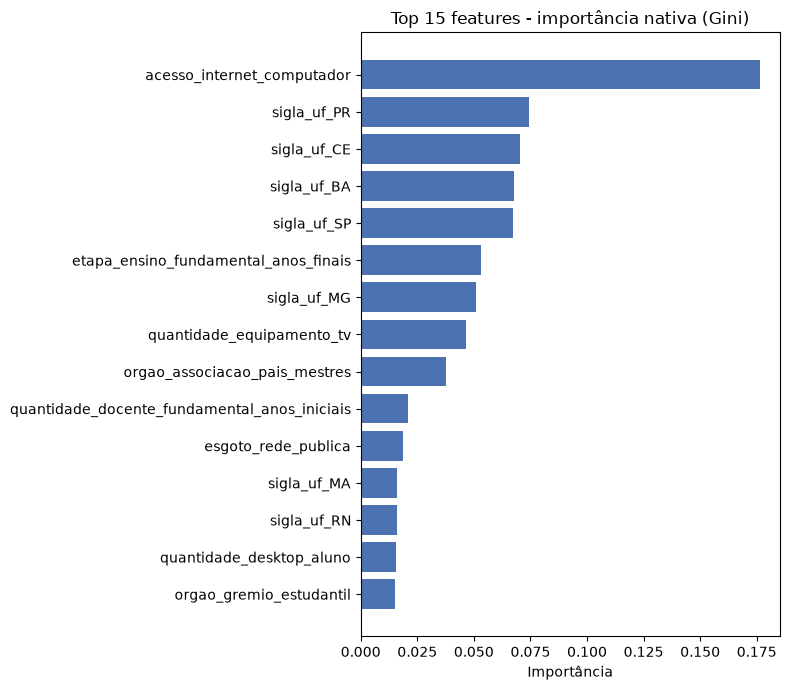

acesso_internet_computador                      0.176447
sigla_uf_PR                                     0.074382
sigla_uf_CE                                     0.070246
sigla_uf_BA                                     0.067731
sigla_uf_SP                                     0.067217
etapa_ensino_fundamental_anos_finais            0.053354
sigla_uf_MG                                     0.050991
quantidade_equipamento_tv                       0.046721
orgao_associacao_pais_mestres                   0.037686
quantidade_docente_fundamental_anos_iniciais    0.020941
esgoto_rede_publica                             0.018672
sigla_uf_MA                                     0.016212
sigla_uf_RN                                     0.016075
quantidade_desktop_aluno                        0.015762
orgao_gremio_estudantil                         0.015041
dtype: float64

In [7]:
nomes_features = pipe_final.named_steps["prep"].get_feature_names_out()
nomes_limpos = [n.split("__", 1)[1] if "__" in n else n for n in nomes_features]

importancias_nativas = pd.Series(
    pipe_final.named_steps["clf"].feature_importances_, index=nomes_limpos,
).sort_values(ascending=False)

plot_importancia_features(importancias_nativas, top_n=15, titulo="Top 15 features - importância nativa (Gini)")
importancias_nativas.head(15)

### 3.1 Desenho da árvore final (primeiros níveis)

Antes de qualquer técnica pós-hoc, vale olhar a própria regra que a árvore aprendeu. Como `max_depth=None` deixa a árvore crescer até o `min_samples_leaf=50` segurar, o desenho completo fica ilegível; limito a exibição aos 3 primeiros níveis (`profundidade_exibicao=3`, que corta só o desenho, não o modelo). O que interessa aqui é a raiz e os primeiros cortes: eles mostram, sem intermediário, quais variáveis a árvore usa primeiro pra separar escola que bate a meta de escola que não bate. É a mesma árvore que o `plot_arvore` desenha no notebook 10 (Seção 10), só que treinada de novo aqui, com a mesma configuração e o mesmo `random_state`.

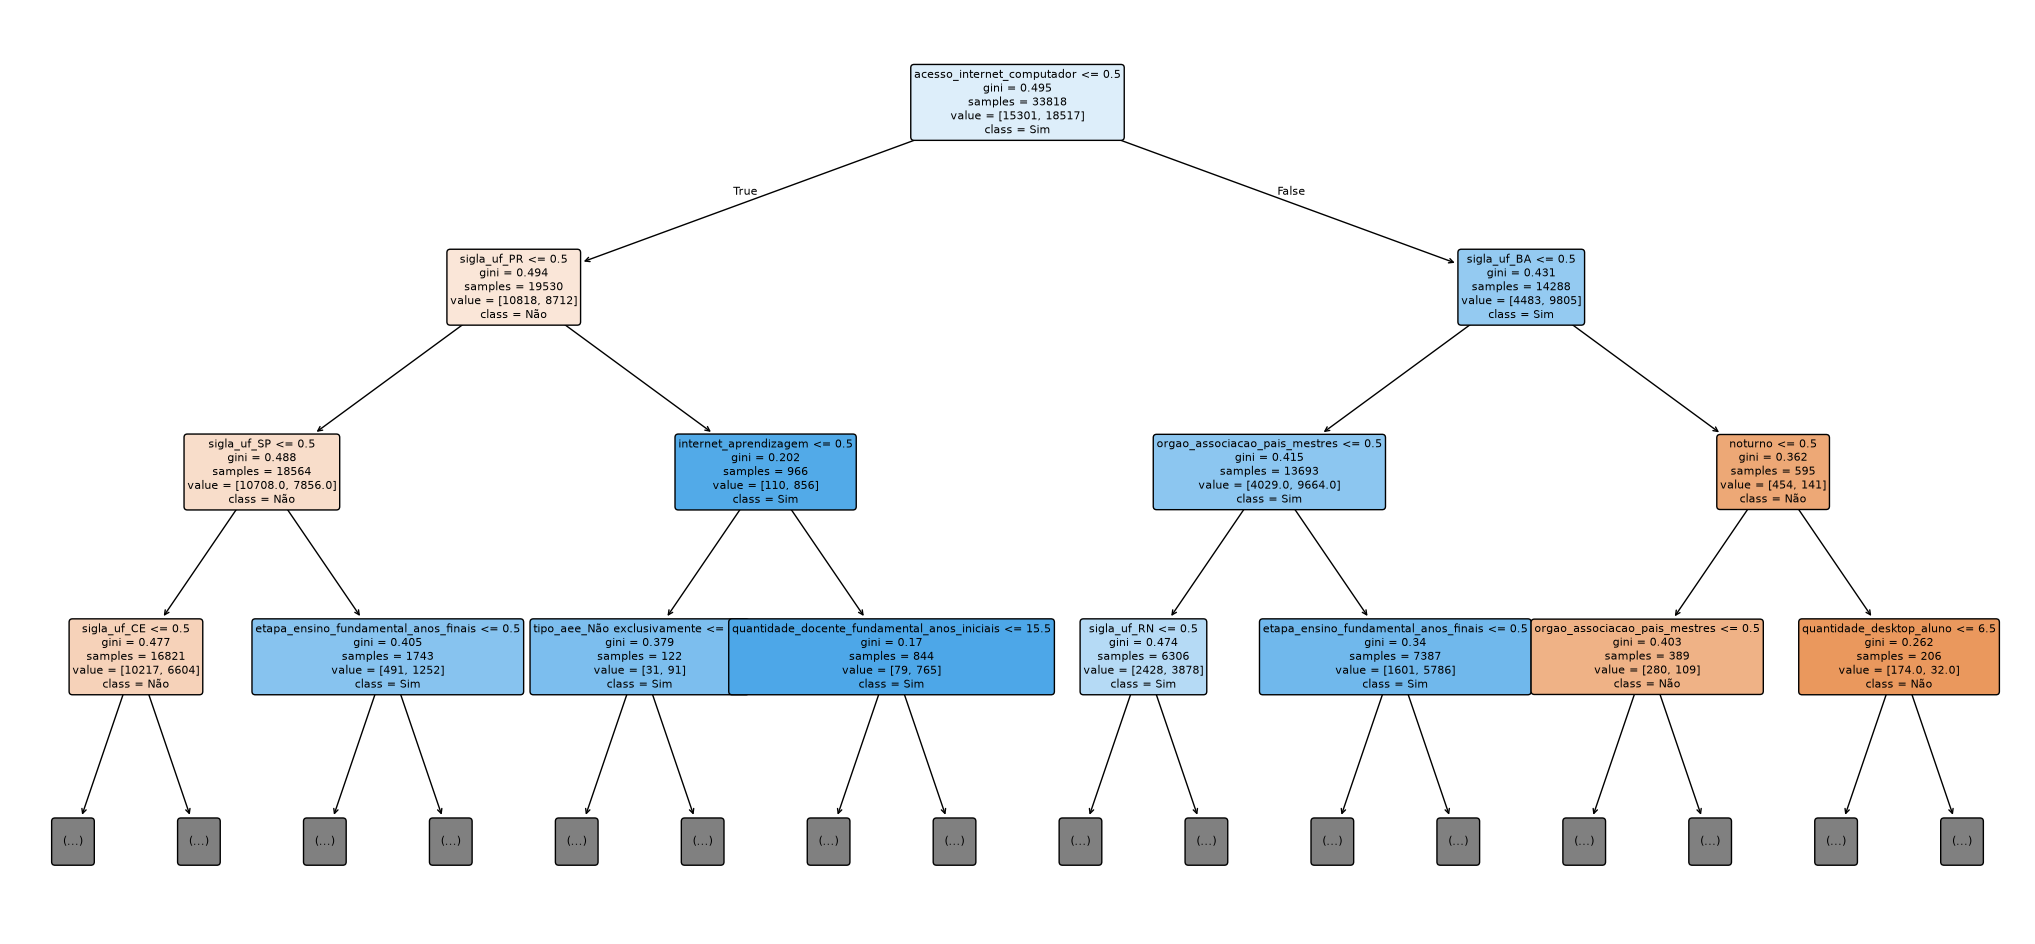

In [8]:
plot_arvore(
    pipe_final.named_steps["clf"], nomes_limpos,
    figsize=(26, 12), profundidade_exibicao=3,
)

## 4. Permutation Importance

A importância nativa tem um viés conhecido: tende a inflar variáveis que aparecem perto da raiz da árvore, mesmo que o ganho real de generalização trazido por elas seja pequeno. `permutation_importance` mede de um jeito mais direto: embaralha uma feature original de cada vez (quebrando a relação dela com o alvo, mantendo tudo mais igual) e mede o quanto a acurácia cai - quanto maior a queda, mais o modelo realmente depende daquela feature. Rodo na validação (dado que o modelo nunca usou pra treinar), com 10 repetições por feature pra ter uma média mais estável, e uso a feature original (antes do One-Hot), não cada categoria separada - é mais interpretável (ex.: importância de `sigla_uf` como um todo, não uma linha por estado).

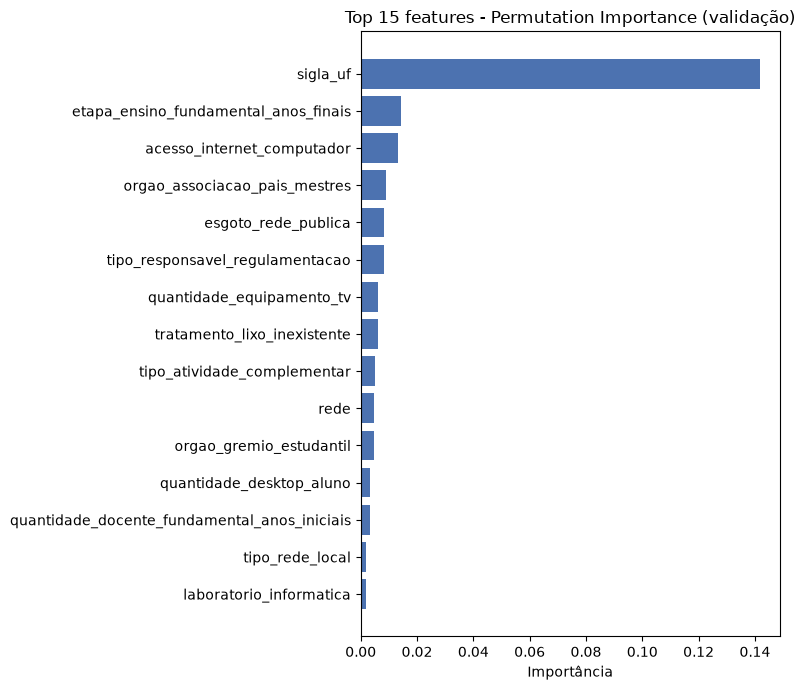

sigla_uf                                        0.141810
etapa_ensino_fundamental_anos_finais            0.014157
acesso_internet_computador                      0.013199
orgao_associacao_pais_mestres                   0.008870
esgoto_rede_publica                             0.008374
tipo_responsavel_regulamentacao                 0.008161
quantidade_equipamento_tv                       0.006245
tratamento_lixo_inexistente                     0.005961
tipo_atividade_complementar                     0.005003
rede                                            0.004861
orgao_gremio_estudantil                         0.004837
quantidade_desktop_aluno                        0.003394
quantidade_docente_fundamental_anos_iniciais    0.003217
tipo_rede_local                                 0.001952
laboratorio_informatica                         0.001928
dtype: float64

In [9]:
resultado_permutacao = permutation_importance(
    pipe_final, X_validacao, y_validacao,
    n_repeats=10, random_state=42, scoring="accuracy", n_jobs=-1,
)

importancias_permutacao = pd.Series(
    resultado_permutacao.importances_mean, index=X_validacao.columns,
).sort_values(ascending=False)

plot_importancia_features(importancias_permutacao, top_n=15, titulo="Top 15 features - Permutation Importance (validação)")
importancias_permutacao.head(15)

### 4.1 Comparando as duas

**Resultado real:** as duas concordam no topo, mas discordam na magnitude relativa de `sigla_uf` - e isso não é uma divergência preocupante, é a diferença de granularidade entre as métricas. A importância nativa lidera com `acesso_internet_computador` (0,176), com `sigla_uf` fatiado em várias dummies individuais (PR 0,074, CE 0,070, BA 0,068, SP 0,067, MG 0,051 - juntas somam mais que o topo isolado, mas aparecem espalhadas). Já a Permutation Importance mede `sigla_uf` inteiro de uma vez: 0,142, dez vezes maior que a segunda colocada (`etapa_ensino_fundamental_anos_finais`, 0,014). Rodando o experimento da Seção 2.2 (sigla_uf como coluna única, sem one-hot), a importância nativa também passa a mostrar `sigla_uf` como uma linha só, e ela vira a maior de todas (0,310) - confirmando que a fragmentação por dummy era o motivo da discrepância, não um problema de viés da árvore pra variáveis com muitos níveis.

## 5. SHAP (TreeExplainer)

SHAP (SHapley Additive exPlanations) distribui a diferença entre a previsão de uma escola específica e a previsão média da base entre as features, de um jeito que soma exatamente essa diferença (propriedade de aditividade) - diferente da importância nativa/permutação, que só falam do modelo como um todo, o SHAP também explica uma previsão individual. Uso o `TreeExplainer`, que calcula o valor exato (não uma aproximação) pra modelos baseados em árvore, de forma rápida.

In [10]:
X_validacao_transformada = pipe_final.named_steps["prep"].transform(X_validacao)
if hasattr(X_validacao_transformada, "toarray"):
    X_validacao_transformada = X_validacao_transformada.toarray()
X_validacao_transformada = pd.DataFrame(
    X_validacao_transformada, columns=nomes_limpos, index=X_validacao.index,
)

explainer = shap.TreeExplainer(pipe_final.named_steps["clf"])
explicacao = explainer(X_validacao_transformada)

# TreeExplainer devolve valor pras duas classes (Não/Sim) - fico só com a
# classe "Sim" (bate a meta do IDEB), a mesma convenção usada no resto do projeto.
explicacao_classe_sim = explicacao[:, :, 1]

### 5.1 Visão geral: beeswarm plot

Cada ponto é uma escola. A posição no eixo horizontal mostra se aquela feature empurrou a previsão daquela escola pra cima (mais perto de bater a meta) ou pra baixo; a cor mostra se o valor da feature era alto (vermelho) ou baixo (azul) pra aquela escola. Isso já responde, de forma visual, não só "quais features importam" mas também "em que direção" - algo que a importância nativa/permutação não mostram sozinhas.

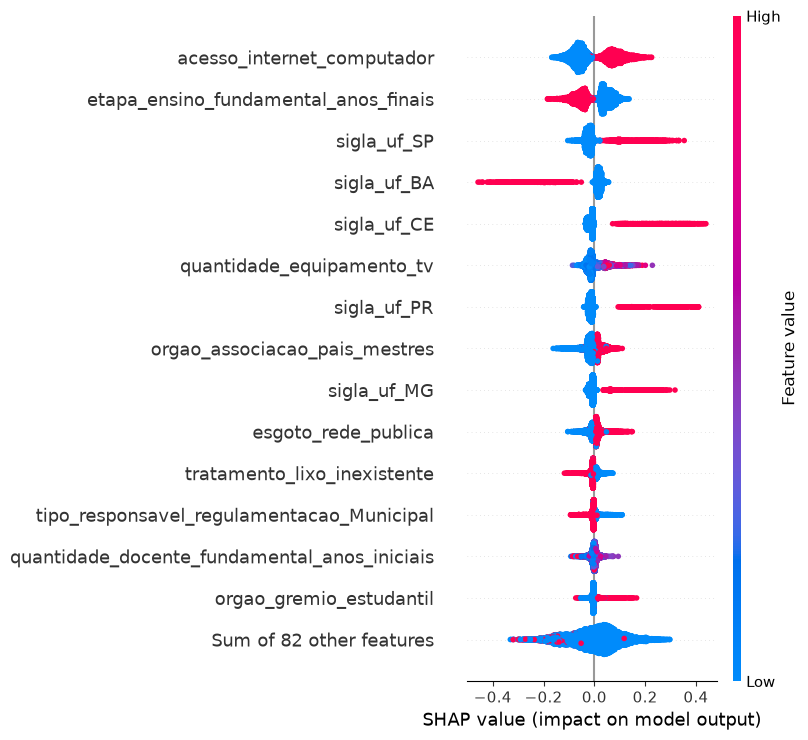

In [11]:
shap.plots.beeswarm(explicacao_classe_sim, max_display=15, show=False)
plt.tight_layout()
plt.show()

### 5.2 Explicando escolas individuais

Tudo até aqui é agregado (o que importa em média, olhando todas as escolas). O SHAP também explica UMA escola específica - importante pra política pública, porque se uma escola for sinalizada como em risco, quem for agir precisa saber exatamente por quê, não só que o modelo "achou" isso.

Escolho duas escolas da validação pra ilustrar: a que o modelo deu a menor probabilidade de bater a meta, e a que deu a maior.

In [12]:
probas_validacao = pipe_final.predict_proba(X_validacao)[:, 1]

idx_risco = int(np.argmin(probas_validacao))
idx_seguro = int(np.argmax(probas_validacao))

print(
    f"Escola em maior risco (id_escola={metadado_validacao.iloc[idx_risco]['id_escola']}, "
    f"sigla_uf={metadado_validacao.iloc[idx_risco]['sigla_uf']}): "
    f"probabilidade de bater a meta = {probas_validacao[idx_risco]:.3f}"
)
print(
    f"Escola mais segura (id_escola={metadado_validacao.iloc[idx_seguro]['id_escola']}, "
    f"sigla_uf={metadado_validacao.iloc[idx_seguro]['sigla_uf']}): "
    f"probabilidade de bater a meta = {probas_validacao[idx_seguro]:.3f}"
)

Escola em maior risco (id_escola=29120527, sigla_uf=BA): probabilidade de bater a meta = 0.000
Escola mais segura (id_escola=41066936, sigla_uf=PR): probabilidade de bater a meta = 1.000


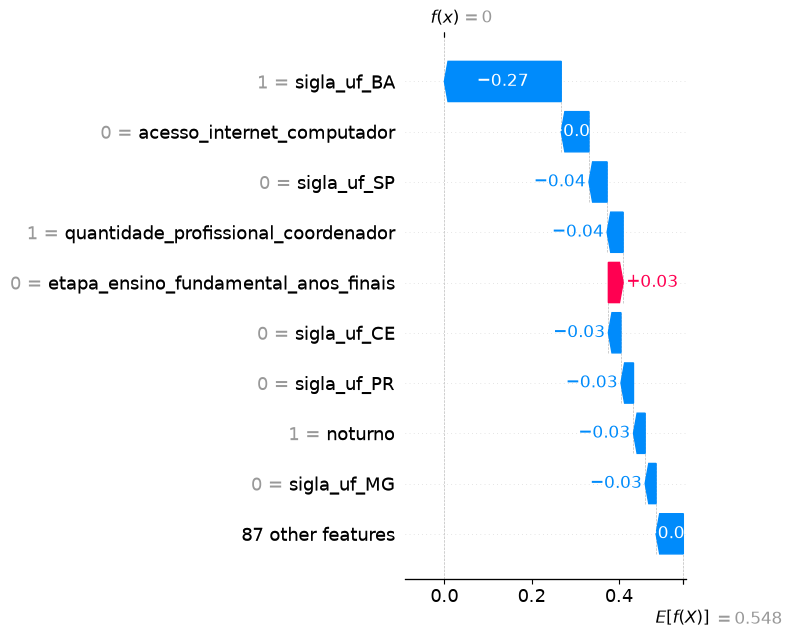

In [13]:
shap.plots.waterfall(explicacao_classe_sim[idx_risco], show=False)
plt.tight_layout()
plt.show()

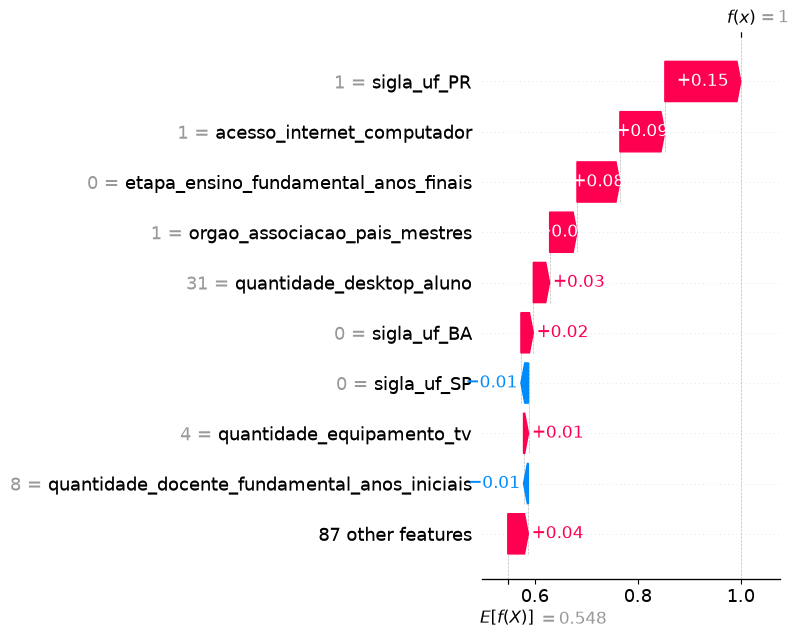

In [14]:
shap.plots.waterfall(explicacao_classe_sim[idx_seguro], show=False)
plt.tight_layout()
plt.show()

## 6. Cruzando com as hipóteses da EDA (Achado 44)

**Resultado real, cruzando com as 5 hipóteses do Achado 44:**

1. **Infraestrutura x IDEB:** confirmada - `acesso_internet_computador` é a feature numérica mais forte nas três técnicas, seguida de esgoto e tratamento de lixo.
2. **`sigla_uf`/`rede` como proxy de governança:** fortemente confirmada, e mais forte do que a EDA já sugeria - `sigla_uf` é a variável isolada mais influente do modelo inteiro pela Permutation Importance (0,142). `rede` aparece bem mais discreta na Permutation Importance (0,0049), então essa hipótese se sustenta principalmente pelo lado do estado, não da rede administrativa.
3. **Tamanho da escola:** não apareceu entre as top 15 de nenhuma das três técnicas (`quantidade_matricula_fundamental_anos_iniciais` não está nem na lista de features finais, foi substituída na prática por variáveis de infraestrutura mais diretas) - hipótese que parecia razoável na EDA mas não se confirmou como determinante pro modelo.
4. **Localização (`tipo_localizacao`, urbano/rural):** não aparece entre as top 15 de nenhuma técnica - o efeito de localização parece estar sendo capturado indiretamente por `sigla_uf` e pelas variáveis de infraestrutura (internet, esgoto), que são mais diretamente urbano/rural do que a própria flag.
5. **Composição racial:** como já esperado (as colunas de raça/cor foram excluídas do conjunto de features por decisão ética, Achado 23), não aparece diretamente em nenhuma técnica - mas o forte peso de `sigla_uf` é compatível com a hipótese de que esse sinal vaza indiretamente pela geografia, já que a composição racial no Brasil tem forte correlação regional.

**Maior surpresa real:** `etapa_ensino_fundamental_anos_finais` (se a escola também oferece 6º-9º ano) apareceu na 2ª posição da Permutation Importance (0,014) - uma hipótese que eu nem tinha formalizado no Achado 44, e que só virou clara depois de ver o SHAP (detalhe na Seção 8, abaixo).

## 7. As 5 perguntas de negócio

A partir daqui, uso o modelo já treinado e fechado (Seção 2) pra gerar respostas aplicadas - **isso não é avaliação do modelo** (isso já foi fechado nos notebooks 10 e 11, com a validação como cofre fechado, e não repito aqui). Pra ter cobertura melhor por município (a validação sozinha, 20% da base, tem poucas ou nenhuma escola em muitos municípios pequenos), aplico o modelo na base inteira (treino + validação) pra gerar um `risco_previsto` por escola. Importante deixar isso explícito: como parte dessas escolas o modelo viu no treino, esse número não serve pra medir a qualidade do modelo - serve só pra gerar o output de negócio, que é um uso legítimo e diferente de avaliação.

In [15]:
probas_completo = pipe_final.predict_proba(X)[:, 1]
risco_previsto = 1 - probas_completo  # probabilidade de NAO bater a meta do IDEB

resultado_escolas = metadado.copy()
resultado_escolas["risco_previsto"] = risco_previsto
resultado_escolas["alvo_real"] = y.values

REGIAO_POR_UF = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}
resultado_escolas["regiao"] = resultado_escolas["sigla_uf"].map(REGIAO_POR_UF)

resultado_escolas.head()

,id_escola,id_municipio,sigla_uf,risco_previsto,alvo_real,regiao
6044,15064662,1500107,PA,0.845070,0,Norte
6301,15021033,1504505,PA,0.949367,0,Norte
6405,15223612,1500701,PA,0.661972,0,Norte
6406,33098018,3300100,RJ,0.768293,0,Sudeste
6407,13134205,1301407,AM,0.915493,0,Norte


### Pergunta 1: Quais fatores mais impactam a alfabetização (a nível de escola)?
### Pergunta 5: Quais variáveis têm mais influência nos modelos?

Trato as duas juntas porque, nesse projeto, a resposta é a mesma tabela: o cruzamento entre a importância nativa (Seção 3), a Permutation Importance (Seção 4) e o SHAP (Seção 5).

**Resposta real, features que aparecem fortes nas três técnicas ao mesmo tempo:**

- **`sigla_uf` (o estado onde a escola está):** de longe o fator mais influente pela Permutation Importance (0,142) e pelo SHAP (efeitos individuais chegando a -0,27 e +0,15 numa única escola, Seção 5.2). Direção: SP, CE, PR e MG empurram pra bater a meta; BA empurra fortemente pro lado contrário.
- **`acesso_internet_computador`:** a feature numérica mais forte nas três técnicas. Direção clara: ter acesso empurra pra bater a meta.
- **`etapa_ensino_fundamental_anos_finais`:** 2ª colocada na Permutation Importance, e apareceu no SHAP também. Direção: escolas que TAMBÉM oferecem anos finais (6º-9º) tendem a ter previsão pior no IDEB dos anos iniciais - dado real da Seção 1.1: 60,5% das escolas que oferecem só anos iniciais batem a meta, contra 47,8% das que oferecem os dois ciclos (quase 13 pontos percentuais de diferença). Fica registrado como achado real, não é definitivo se é causal (pode ser proxy de escola maior/mais heterogênea, não necessariamente menos focada).
- **Infraestrutura básica (esgoto, tratamento de lixo, orgão de associação de pais e mestres):** aparecem de forma consistente, mas com peso bem menor que os dois primeiros itens.

### Pergunta 2: Quais municípios apresentam maior risco educacional?

In [16]:
risco_por_municipio = (
    resultado_escolas.groupby(["id_municipio", "sigla_uf"])
    .agg(risco_medio=("risco_previsto", "mean"), n_escolas=("risco_previsto", "size"))
    .reset_index()
)

# So municipios com pelo menos 3 escolas na base, pra a media nao ficar
# instavel por causa de 1 unica escola isolada.
risco_por_municipio_filtrado = risco_por_municipio[risco_por_municipio["n_escolas"] >= 3]

top_10_municipios_risco = risco_por_municipio_filtrado.sort_values("risco_medio", ascending=False).head(10)
top_10_municipios_risco

,id_municipio,sigla_uf,risco_medio,n_escolas
1986,2913804,BA,1.000000,3
2036,2918308,BA,0.959234,7
1928,2908903,BA,0.953064,7
2016,2916609,BA,0.953052,3
1840,2901700,BA,0.945964,5
1786,2804300,SE,0.943396,3
1763,2802007,SE,0.943396,3
75,1300060,AM,0.942360,5
1960,2911501,BA,0.939061,3
1965,2911857,BA,0.938611,5


### Pergunta 3: Quais regiões têm padrões semelhantes?

In [17]:
risco_por_regiao = resultado_escolas.groupby("regiao")["risco_previsto"].mean().sort_values(ascending=False)
risco_por_uf = resultado_escolas.groupby("sigla_uf")["risco_previsto"].mean().sort_values(ascending=False)

print("Risco médio previsto por região:")
print(risco_por_regiao)
print("\nRisco médio previsto por UF (10 mais arriscadas):")
print(risco_por_uf.head(10))

Risco médio previsto por região:
regiao
Norte           0.682594
Nordeste        0.635468
Centro-Oeste    0.419756
Sudeste         0.301212
Sul             0.243011
Name: risco_previsto, dtype: float64

Risco médio previsto por UF (10 mais arriscadas):
sigla_uf
BA    0.801196
MA    0.800335
RN    0.770617
PA    0.755889
SE    0.753949
AP    0.675519
TO    0.651184
PE    0.650586
MS    0.621028
AC    0.615808
Name: risco_previsto, dtype: float64


**Resultado real: bate muito bem com o Achado 27.** As 5 UFs mais arriscadas pelo modelo são BA (0,801), MA (0,800), RN (0,771), PA (0,756) e SE (0,754) - exatamente o grupo que o Achado 27 já tinha identificado como atrás na EDA (MA/PA/RN/SE/AP). SP não aparece entre as 10 mais arriscadas - consistente com o Achado 27 apontar SP na frente. Por região, o padrão também confirma: Norte (0,683) e Nordeste (0,635) com risco médio bem mais alto que Sudeste (0,301) e Sul (0,243). Como `sigla_uf` é feature direta do modelo, essa confirmação é esperada - o que isso significa na prática é que o modelo aprendeu bem um padrão regional que já era conhecido, em vez de descobrir algo inédito. O valor agregado do modelo aqui não é revelar que o Nordeste tem mais risco (isso já se sabia), e sim apontar, dentro de cada região, exatamente QUAIS escolas e municípios específicos estão nessa situação, pra viabilizar ação direcionada.

### Pergunta 4: Como prever/identificar escolas e municípios que podem não atingir metas futuras?

O `risco_previsto` calculado na Seção 7 (a probabilidade de NÃO bater a meta do IDEB, segundo o modelo) já É essa resposta prática: qualquer escola nova, com as mesmas características medidas pelo Censo Escolar, pode ser passada pelo mesmo pipeline e receber esse mesmo score, sem precisar esperar o resultado real do próximo ciclo do IDEB pra saber se está em risco.

**Limitação importante de deixar explícita:** isso não é uma previsão de série temporal - o modelo foi treinado com um único ciclo (IDEB 2025 x Censo 2024, Achado 17), não aprendeu tendência ao longo dos anos. O que ele projeta é "dado o perfil atual desta escola, qual o risco de não bater a meta", assumindo que a relação entre infraestrutura/governança e desempenho continua parecida - a mesma suposição, aliás, que já sustentava o pareamento de ano entre Censo e IDEB (Achado 17). Se o objetivo fosse projetar uma tendência real ao longo do tempo, precisaria de dado histórico de várias safras do IDEB por escola, o que está fora do escopo definido aqui.

### Priorizacao de escolas para intervencao, por faixa de risco

As perguntas de negocio pedem uma lista acionavel de escolas em risco, nao so uma media por municipio/regiao. Uso a mesma probabilidade prevista (`risco_previsto`) de cada escola, mas agora olhando so pra quem o modelo ja classifica como 'nao vai bater a meta' (`risco_previsto >= 0,5`, equivalente a classe prevista 'Nao' no limiar padrao de 0,5) e separo em 3 faixas de prioridade pra orientar onde agir primeiro:

- **Prioridade alta** (`risco_previsto >= 0,90`): o modelo esta bastante confiante que a escola nao vai bater a meta.
- **Prioridade media** (`0,80 <= risco_previsto < 0,90`).
- **Prioridade baixa** (`0,50 <= risco_previsto < 0,80`): a escola ja fica do lado 'nao vai bater', mas com menos confianca - caso limitrofe.

Escolas com `risco_previsto < 0,50` (o modelo ja preve que batem a meta) ficam de fora dessa lista - o objetivo aqui e ação sobre quem esta em risco, nao uma lista com as ~42 mil escolas da base de modelagem inteira.

In [18]:
def classificar_prioridade(risco):
    if risco >= 0.90:
        return "Alta"
    elif risco >= 0.80:
        return "Média"
    elif risco >= 0.50:
        return "Baixa"
    return None  # nao entra na lista - modelo ja preve que bate a meta

resultado_escolas["prioridade"] = resultado_escolas["risco_previsto"].apply(classificar_prioridade)
escolas_em_risco = resultado_escolas[resultado_escolas["prioridade"].notna()].copy()

print(f"Total de escolas na base: {len(resultado_escolas):,}")
print(f"Escolas classificadas como em risco (risco_previsto >= 0,50): {len(escolas_em_risco):,} "
      f"({len(escolas_em_risco) / len(resultado_escolas) * 100:.1f}%)")
print()
print("Distribuicao por faixa de prioridade:")
print(escolas_em_risco["prioridade"].value_counts().reindex(["Alta", "Média", "Baixa"]))
print()
print("Escolas em risco por regiao e faixa de prioridade:")
print(escolas_em_risco.groupby(["regiao", "prioridade"]).size().unstack(fill_value=0).reindex(columns=["Alta", "Média", "Baixa"]))
print()
print("Prioridade Alta, top 10 escolas por risco:")
escolas_em_risco[escolas_em_risco["prioridade"] == "Alta"].sort_values("risco_previsto", ascending=False).head(10)


Total de escolas na base: 42,273
Escolas classificadas como em risco (risco_previsto >= 0,50): 18,252 (43.2%)

Distribuicao por faixa de prioridade:
prioridade
Alta      2651
Média     3396
Baixa    12205
Name: count, dtype: int64

Escolas em risco por regiao e faixa de prioridade:
prioridade    Alta  Média  Baixa
regiao                          
Centro-Oeste    28     33    833
Nordeste      1860   2192   6447
Norte          702    920   2118
Sudeste         42    236   2014
Sul             19     15    793

Prioridade Alta, top 10 escolas por risco:


,id_escola,id_municipio,sigla_uf,risco_previsto,alvo_real,regiao,prioridade
56940,29098424,2913804,BA,1.0,0,Nordeste,Alta
60846,29997828,2905404,BA,1.0,0,Nordeste,Alta
14036,29331471,2925303,BA,1.0,0,Nordeste,Alta
13995,29145910,2930501,BA,1.0,0,Nordeste,Alta
13534,29428661,2906709,BA,1.0,0,Nordeste,Alta
60845,29429943,2926509,BA,1.0,0,Nordeste,Alta
6907,29118123,2910701,BA,1.0,0,Nordeste,Alta
9116,29265487,2931806,BA,1.0,0,Nordeste,Alta
56053,29475899,2928901,BA,1.0,0,Nordeste,Alta
7442,29286468,2905800,BA,1.0,0,Nordeste,Alta


## 8. Revisão: os insights fazem sentido pra política pública?

Alguns cuidados de interpretação que já vinham sendo registrados ao longo do projeto valem repetir aqui, porque ficam mais concretos agora que o modelo está de pé e gerando número real:

- **Correlação não é causalidade (Achado 29).** Se uma variável de infraestrutura aparecer no topo da importância, a leitura correta é "escolas com esse recurso tendem a também ter outros fatores associados a melhor desempenho", não "instalar esse item específico causa o resultado".
- **`sigla_uf` carrega sinal de governança estadual, não só geografia (Achado 36).** Se aparecer com importância alta, a leitura é sobre a gestão da rede estadual daquele estado específico, não sobre clima/cultura da região.
- **As colunas de raça/cor foram excluídas do modelo por decisão ética (Achado 23).** O sinal racial não aparece diretamente em nenhuma das três técnicas porque a variável simplesmente não existe no conjunto de features - mas pode estar vazando indiretamente via `sigla_uf`/localização, uma limitação que já estava registrada e que vale repetir no relatório final.

**Duas surpresas reais que vale registrar:**

1. **A diferença de proporção que bate a meta por `etapa_ensino_fundamental_anos_finais` (60,5% x 47,8%) foi maior do que eu esperava** quando só tinha a intuição do SHAP - quase 13 pontos percentuais é uma diferença grande pra uma característica estrutural da escola (oferecer ou não um ciclo extra), e não uma característica de infraestrutura/investimento como as demais do topo do ranking.
2. **O Ceará aparecer entre os estados que mais empurram pra bater a meta (sigla_uf_CE) no SHAP** é coerente com um resultado conhecido em política educacional brasileira (desempenho acima do esperado pra renda da região), mas foi uma confirmação que o modelo trouxe sozinho, sem eu ter informado esse contexto de propósito - reforça que `sigla_uf` está capturando governança estadual de verdade, não só um proxy vazio.

## 9. Síntese

**Síntese:** as três técnicas de interpretabilidade convergem num retrato consistente - o estado onde a escola está (`sigla_uf`) é, isoladamente, o fator mais influente sobre a previsão (Permutation Importance 0,142, dez vezes maior que qualquer outra feature), seguido por acesso à internet/computador e, de forma mais sutil mas real, se a escola também oferece os anos finais do Fundamental. O padrão regional confirma a EDA (Achado 27): Nordeste e Norte concentram o maior risco previsto, com Bahia isoladamente a UF mais arriscada. A aplicação prática (Seção 7) transforma isso numa lista de 2.651 escolas de prioridade Alta pra intervenção direta, concentradas majoritariamente no Nordeste. A leitura de política pública mais importante: o modelo não está dizendo que 'nascer' num certo estado condena a escola - está apontando onde a gestão e o investimento estadual (rede pública, governança, infraestrutura) parecem fazer a maior diferença, e é justamente aí que a ação tem mais alavancagem. A versão consolidada e revisada desta seção, junto com as respostas formais às 5 perguntas de negócio, está em `reports/insights.md`.